This second notebook reduces the galaxy and standard star data files.

The steps involved:
1. Create galaxy/star frames with error information
2. Divide out exposure time from each pixel
3. Dome divide the galaxy/star frames
4. Sky subtract the galaxy/star frame so that we get rid of most sky emission lines (vertical across the frame)
5. Flux calibrate galaxy so that our flux makes sense
    -Done using literature values of standard star flux data and its observed counts in the CCD camera
6. Correct for galactic extinction

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

Links to Files that are needed:


Observing Logs: https://docs.google.com/spreadsheets/d/19v4nBcECCigROeGPS2rwiysORTBjCffDcB341-r922Y/edit#gid=1194970769

SPOGs Catalog: https://docs.google.com/spreadsheets/d/1c5fgdHtlREJJa74qoYHdB50PKTbu9OYMQv3rLcRnHWg/edit?usp=sharing

Galaxy Cell Inputs (for the only cell we change when running this notebook): https://docs.google.com/document/d/1X3sOMGisplLTeqPYJeXflmHIlAvsFCyVPc8UgKXjhaU/edit?usp=sharing 

Note: Make sure not to accidentally change something in the google sheets files

In [4]:
#These are the python packages that are needed for the full code. If you get an error, that means some package
#must be installed on python

from astropy.io import fits
import astropy
import matplotlib.pyplot as plt
import numpy as np
import datetime
import glob
from scipy.optimize import curve_fit
from numpy import loadtxt
from matplotlib.backends.backend_pdf import PdfPages
from astropy import units as u
from astropy.io.fits import Header
import os
import astropy.stats as ap
from astropy.io import fits
from astropy.modeling import models, fitting
from astropy.modeling.models import custom_model
from astropy.modeling import Fittable1DModel, Parameter
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np
import math
import numpy.polynomial.polynomial as poly
import extinction
import fnmatch
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats

**First Part of code to change**

In the following cell, change all the input variables. 


**Note:** This should be the only cell you need to change things in. At the end of the code, double check that the column fit is working (before the header input). If it is not, you will need to change that part of the code too.

In [6]:
#In this cell, we will be changing the inputs required throughout the rest of the pipeline
path = "/Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/"#This is the file path to the main reduction
galaxy_name = "J0800+3743_major" #Using our observing logs, this is the galaxy's name that we want to reduce
galaxy_name_2 = "J0800+3743"
galaxy_file_name = galaxy_name #Same as last line (Artifact of a past code that needed 2)
standard_star_name = "HR3454" #Standard star name (Also observed right before/after our galaxy)
date = "2-16" #observation date as a number
date_link = "Feb 16 2020" # observation date
RA = 120.1986 #galaxy's RA value from SPOGs catalog
Dec = 37.7287 #galaxy's Dec value from SPOGs catalog
setting = "A" #Should be an A or B. This refers to the wavelength range observed.
#The observing logs should indicate which
#Using observing logs, this is the file numbers for the bias calibration frames that we took
bias_files = [16, 17, 18, 19,20, 21, 22, 23, 24, 25]
#Using observing logs, this is the file numbers for the dome flat calibration frames that we took
dome_flat_files = [26, 27, 28, 29, 30]
#Using observing logs, this is the file numbers for the arc calibration frames that we took
arc_files = [11, 12, 13, 14, 15]
#Using observing logs, this is the file numbers for the galaxy files
galaxy_files = [37,38,39,40]
number_of_galaxy_files = len(galaxy_files)
galaxy_exposure_times = [900, 900, 900,900]
#Using observing logs, this is the file numbers for the star files
star_files = [35,36]
number_of_star_files = len(star_files)
star_exposure_times = [1, 1]
literature_standard_star_values = "HR3454.txt"
target_row = 141
target_row_script = "141"

In [7]:
#This is just a value for us to compare our spectra to SDSS in a later notebook using a txt file created
# in this notebook
flux_correction = 10 **17

In [8]:
#Create Log file that includes all the settings above.
#We do this in the first notebook, but it's never a bad idea to just double check that we are using the
# right files!
with open(path + "Observations/" + date_link +'/LOGFILE/' + galaxy_name + '_' + 'LOGFILE_v2_5.txt','w') as f:
    f.write('Path:')
    f.write(path) 
    f.write("\n")
    f.write('Galaxy Name:')
    f.write(galaxy_name)
    f.write("\n")
    f.write('Galaxy Name 2:')
    f.write(galaxy_name_2)
    f.write("\n")
    f.write('G File Name:')
    f.write(galaxy_file_name) 
    f.write("\n")
    f.write('Standard Star Name:')
    f.write(standard_star_name) 
    f.write("\n")
    f.write('Observation Date:')
    f.write(date) 
    f.write("\n")
    f.write('Observation Date Link:')
    f.write(date_link) 
    f.write("\n")
    f.write('Galaxy RA:')
    f.write(str(RA)) 
    f.write("\n")
    f.write('Galaxy Dec:')
    f.write(str(Dec)) 
    f.write("\n")
    f.write('Galaxy Redshift Setting:')
    f.write(setting) 
    f.write("\n")  
    f.write('Bias File Numbers Used:')
    f.write("\n")
    f.write(str(bias_files))  
    f.write("\n")
    f.write('Dome Flat File Numbers Used:')
    f.write("\n")
    f.write(str(dome_flat_files)) 
    f.write("\n")
    f.write('Arc Frame File Numbers Used:')
    f.write("\n")
    f.write(str(arc_files)) 
    f.write("\n")
    f.write('Number of Galaxy frames median combined:')
    f.write("\n")
    f.write(str(number_of_galaxy_files)) 
    f.write("\n") 
    f.write('Galaxy Frame File Numbers:')
    f.write("\n")
    f.write(str(galaxy_files)) 
    f.write("\n")    
    f.write('Galaxy Frame Exposure Time:')
    f.write("\n")
    f.write(str(galaxy_exposure_times)) 
    f.write("\n")
    f.write('Number of Standard Star frames to be median combined:')
    f.write("\n")
    f.write(str(number_of_star_files)) 
    f.write("\n")
    f.write('Standard Star Frame File Numbers:')
    f.write("\n")
    f.write(str(star_files)) 
    f.write("\n")
    f.write('Standard Star Frame Exposure Time:')
    f.write("\n")
    f.write(str(star_exposure_times)) 
    f.write("\n")
    f.write('Standard Star Literature Value Txt File Used:')
    f.write(literature_standard_star_values) 
    f.write("\n")
    f.write('Target Row:')
    f.write(str(target_row))
    f.write("\n")
    f.write(target_row_script) 
    f.write("\n")

In [38]:
#Function for defining error in dome flat individual frames, galaxy frames, and standard star frames

def ErrorExtension(file_number,FrameName):
    #Open the file and extract the data into an ndarray
    finding4 = fnmatch.filter(os.listdir(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/."), '*' + 'File_' + str(file_number) + '.fits')
    print(finding4)
    
    #bias_subtracted_files = sorted(glob.glob(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/*.fits"),key=os.path.getmtime)
    bias_subtracted = fits.open(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/" + finding4[0])
    arraydata = bias_subtracted[0].data
    #Create error frame, same shape as data array but is empty 
    Error = np.zeros_like(arraydata)
    FrameError = 0
    G = 1.52 #Gain Value
    array = np.array(arraydata)
    float_array = array.astype(np.float32) #converting array into float values
    #We define the frame error of Dome/galaxy/star file as electron counts / gain
    xf=float_array/G #converting counts into photon numbers
    FrameError = xf+(bias_error)**2 + (4.9/(1.52**2))**2#Make sure the creation of the master bias step has been done
    FrameError = np.sqrt(FrameError)
    
    #Plotting the target row of frame and saving it (from cell input above)
    plt.figure(figsize=(15,5))
    rowz_slice = np.resize(FrameError[target_row-1:target_row,:], 2042)
    plt.plot(rowz_slice)
    plt.title("Row "+ target_row_script +" Error " + FrameName + ";  " + date)
    plt.xlabel("Column Number")
    plt.ylabel("Error [" + FrameName + "] " + galaxy_name + " (st. dev.)")
    if not os.path.exists(path + "Working Files/Error Propagation/Dome Science Raw Error/"):
        os.makedirs(path + "Working Files/Error Propagation/Dome Science Raw Error/")
    plt.savefig(path + "Working Files/Error Propagation/Dome Science Raw Error/" + FrameName + date + " " + galaxy_name + ".jpg",bbox_inches='tight')
    plt.close()
       
    #adding the calculated error onto the domeflat frame as a seperate extension
    Frame= fits.PrimaryHDU(arraydata)
    EFrame = fits.ImageHDU(FrameError)
    Frame_Extended = fits.HDUList([Frame,EFrame])
    Frame_Extended.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + FrameName + ".fits",overwrite=True)

    #Error_Added_File = sorted(glob.glob(path + "Data Reduction Error Propagation/Output Data Cubes/" +FrameName + ".fits"))
    frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" +FrameName + ".fits")
    frame.info()
    return frame.close()

In [40]:
#When we combine galaxy files, we want them to be at the same row. 
#This function rolls the combined peaks of the spectra so that the galaxy or star center 
# is at the same row. 
def CenteredRow(name):
    target_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + name + ".fits")
    target_data = target_frame[0].data
    target_error = target_frame[1].data
    
    x_axis = target_data[:, 860:1000]
    temp_x_axis = []
    
    for row in range((target_data.shape[0])):
        temp_x_axis.append(target_data[row, 860:1000])
    plt.imshow(temp_x_axis)
    plt.close()
    temp_med = []
    
    for row in range(482):
        med = np.median(temp_x_axis[row])
        temp_med.append(med)
    #Plotting the fit to each galaxy/star file to find the offset from a central row and shift to it
    #NOTE: this should always find a peak in the 200ish row range. There SHOULD be no issue
    #HOWEVER: In some cases, there are more objects in frame than just the galaxy.
    #IF something wonky is happening, it's because the fit is picking up another object and not the galaxy
    #SO check out the working files directory to see if that's the case. . . 
    x_axis_line_fit = np.linspace(1,482,482)
    plt.plot(x_axis_line_fit, temp_med)
    plt.title("Median Combined Central Column Slice" ,color="black", loc='right')
    plt.xlabel('Pixel  Row Number')
    plt.ylabel('Flux')
    if not os.path.exists(path + "Working Files/Centering/"+name +"/"):
        os.makedirs(path + "Working Files/Centering/"+name +"/")
    plt.savefig(path + "Working Files/Centering/"+name +"/"+name +" Slice.pdf")
    plt.close()
    maxium = max(temp_med)
    index_max = max(range(len(temp_med)), key=temp_med.__getitem__)
    
    compound_model_bounded = models.Gaussian1D(maxium, index_max, 5) + models.Polynomial1D(degree=1)
    delta = 15
    compound_model_bounded.mean_0.max = index_max + delta 
    compound_model_bounded.mean_0.min = index_max - delta

    fitter = fitting.LevMarLSQFitter()
    compound_fit_bounded = fitter(compound_model_bounded, x_axis_line_fit,temp_med)
    
    #The actual fit plot mentioned above
    plt.figure(figsize=(8,5))
    plt.plot(x_axis_line_fit,temp_med, color='k', label = "Stacked Galaxy Column")
    plt.plot(x_axis_line_fit, compound_fit_bounded(x_axis_line_fit), color='darkorange', label = "Gaussian Fit")
    
    #plt.title("Gaussian Fit Central Columns to Find Center Row" ,color="black", loc='right')
    plt.xlabel('Spatial Row (Pixel Count)', fontsize = 14)
    plt.ylabel('Bias-Subtracted Flux (Electron Counts)', fontsize = 14)
    plt.tick_params(axis='x', labelsize=14)  # Change x-axis tick label size
    plt.tick_params(axis='y', labelsize=14)  # Change x-axis tick label size
    
    plt.legend(fontsize = 14, loc='upper left')
    plt.tight_layout()
    if not os.path.exists(path + "Working Files/Centering/"+name +"/Fit/"):
        os.makedirs(path + "Working Files/Centering/"+name +"/Fit/")
    plt.savefig(path + "Working Files/Centering/"+ name +"/Fit/"+name +" Fit Slice.png")
    plt.savefig(path + "Working Files/Centering/"+ name +"/Fit/"+name +" Fit Slice.pdf")
    plt.close()

    #Shifting so that all the galaxy/star files are centered at the same row
    central_shift = 241 - np.round(compound_fit_bounded.parameters[1])
    central_shift = int(central_shift)
    
    rolled = np.roll(target_data,central_shift,0)
    rolled_error = np.roll(target_error,central_shift,0)
    
    #plt.imshow(rolled)
    
    #Writing the rolled file to a fits file
    hdu_data = fits.PrimaryHDU(rolled)
    hdu_error = fits.ImageHDU(rolled_error)
    
    centered_target = fits.HDUList([hdu_data,hdu_error])
    if not os.path.exists(path + "Working Files/Centering/"+name +"/Centered Target/"):
        os.makedirs(path + "Working Files/Centering/"+name +"/Centered Target/")
    centered_target.writeto(path + "Working Files/Centering/"+name +"/Centered Target/"+ name +" Rolled.fits",output_verify='fix',overwrite=True)
    centered_target.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/Rolled " + name + ".fits",output_verify='fix',overwrite=True)

In [43]:
#In this cell, we apply the last two functions to each galaxy/star file, along with new functions

#1: we create error extensions to each
#2: we shift the galaxy and error extensions to a central row if they are offset
#3: we divide each galaxy/star file by their respective exposure times 

bias_subtracted_files = sorted(glob.glob(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/*.fits"),key=os.path.getmtime)

#For some dumb reason, I need to open and load in the bias data file for error propagation...
#I guess it makes sense for me to do that here
bias = fits.open(path + "Observations/" + date_link + "/Trimmed Data/Median_Master_bias.fits")
bias.info()
bias_error = bias[1].data


galaxyfile = open(path + "Observations/" + date_link +'/LOGFILE/Galaxy File Numbers ' + galaxy_name + ' LOGFILE.txt', 'w')
galaxyfile.write("Galaxy File Numbers:")
galaxyfile.write("\n")
for i in range(number_of_galaxy_files):
    #write file to log file
    galaxyfile.write(bias_subtracted_files[galaxy_files[i]]+"\n") 
    #name galaxy file to be used in functions
    galaxyn = galaxy_name + "_" + str(i+1)
    #1: we create error extensions to each
    ErrorExtension(galaxy_files[i],galaxyn)
    #2: we shift the galaxy and error extensions to a central row if they are offset
    CenteredRow(galaxyn)
    
    gal_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/Rolled " + galaxy_name + "_"+ str(i+1) +".fits")
    #3: we divide each galaxy file by their respective exposure times 
    print("GALAXY EXPOSURE TIMES: ", galaxy_exposure_times[i])
    print("galaxy data raw: ", gal_frame[0].data)
    gal_data = gal_frame[0].data/galaxy_exposure_times[i]
    print("galaxy data divided: ", gal_data)
    gal_error_data = gal_frame[1].data/galaxy_exposure_times[i]
    hdu_gal = fits.PrimaryHDU(gal_data)
    Error_Gal_Frame = fits.ImageHDU(gal_error_data)
    G_Frame = fits.HDUList([hdu_gal,Error_Gal_Frame])
    G_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + galaxy_name + "_ET_"+ str(i+1) +".fits",overwrite=True)

galaxyfile.close()
    
starfile = open(path + "Observations/" + date_link +'/LOGFILE/Star File Numbers ' + standard_star_name + ' LOGFILE.txt', 'w')
starfile.write("Star File Numbers:")
starfile.write("\n")
for j in range(number_of_star_files):
    #write file to log file
    starfile.write(bias_subtracted_files[star_files[j]]+"\n")
    #name star file to be used in functions
    starn = standard_star_name + "_" + str(j+1)
    #1: we create error extensions to each
    ErrorExtension(star_files[j],starn)
    #2: we shift the star and error extensions to a central row if they are offset
    CenteredRow(starn)
    
    ststar_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/Rolled " + standard_star_name + "_"+str(j+1)+".fits")
    #3: we divide each star file by their respective exposure times
    ststar_data = ststar_frame[0].data/star_exposure_times[j]
    ststar_error_data = ststar_frame[1].data/star_exposure_times[j]
    hdu_ststar = fits.PrimaryHDU(ststar_data)
    Error_ststar_Frame = fits.ImageHDU(ststar_error_data)
    S_Frame = fits.HDUList([hdu_ststar,Error_ststar_Frame])
    S_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + standard_star_name + "_ET_" + str(j+1) + ".fits",overwrite=True)

starfile.close()

Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Median_Master_bias.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2042, 482)   float64   
  1                1 ImageHDU         7   (2042, 482)   float64   
['J0800+3743_Major_File_37.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/J0800+3743_major_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2042, 482)   float64   
  1                1 ImageHDU         7   (2042, 482)   float64   


/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/165493219.py:20: RuntimeWarning: invalid value encountered in sqrt
  FrameError = np.sqrt(FrameError)


GALAXY EXPOSURE TIMES:  900
galaxy data raw:  [[12.   7.   6.5 ...  8.   6.   2.5]
 [ 5.   9.   1.5 ...  9.   7.5  5.5]
 [ 7.5  0.5  5.5 ...  3.   5.5  4.5]
 ...
 [ 8.5  6.   7.5 ...  7.  10.5  5.5]
 [ 7.   6.   4.  ...  5.   7.  12.5]
 [11.5  4.5  6.5 ...  6.   6.   9. ]]
galaxy data divided:  [[0.01333333 0.00777778 0.00722222 ... 0.00888889 0.00666667 0.00277778]
 [0.00555556 0.01       0.00166667 ... 0.01       0.00833333 0.00611111]
 [0.00833333 0.00055556 0.00611111 ... 0.00333333 0.00611111 0.005     ]
 ...
 [0.00944444 0.00666667 0.00833333 ... 0.00777778 0.01166667 0.00611111]
 [0.00777778 0.00666667 0.00444444 ... 0.00555556 0.00777778 0.01388889]
 [0.01277778 0.005      0.00722222 ... 0.00666667 0.00666667 0.01      ]]
['J0800+3743_Major_File_38.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/J0800+3743_major_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1

/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/165493219.py:20: RuntimeWarning: invalid value encountered in sqrt
  FrameError = np.sqrt(FrameError)


GALAXY EXPOSURE TIMES:  900
galaxy data raw:  [[ 3.5  7.5  4.5 ...  3.   5.5  4.5]
 [ 9.5  1.5  7.  ...  5.5  6.5  9. ]
 [ 1.   7.5 10.5 ...  6.   3.5  5.5]
 ...
 [10.5 -0.5  1.5 ...  3.   0.   4. ]
 [ 4.   6.   8.5 ...  7.   5.   8.5]
 [ 0.  13.   1.5 ...  1.   1.5  6.5]]
galaxy data divided:  [[ 0.00388889  0.00833333  0.005      ...  0.00333333  0.00611111
   0.005     ]
 [ 0.01055556  0.00166667  0.00777778 ...  0.00611111  0.00722222
   0.01      ]
 [ 0.00111111  0.00833333  0.01166667 ...  0.00666667  0.00388889
   0.00611111]
 ...
 [ 0.01166667 -0.00055556  0.00166667 ...  0.00333333  0.
   0.00444444]
 [ 0.00444444  0.00666667  0.00944444 ...  0.00777778  0.00555556
   0.00944444]
 [ 0.          0.01444444  0.00166667 ...  0.00111111  0.00166667
   0.00722222]]
['J0800+3743_Major_File_39.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/J0800+3743_major_3.fits
No.    Name      Ver    Type      Cards   

...

/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/165493219.py:20: RuntimeWarning: invalid value encountered in sqrt
  FrameError = np.sqrt(FrameError)


GALAXY EXPOSURE TIMES:  900
galaxy data raw:  [[ 9.5  1.5  5.  ...  2.5  9.5  3. ]
 [ 4.  13.5  3.5 ...  3.   9.5  3.5]
 [10.5  9.   7.  ...  8.   5.  10.5]
 ...
 [ 7.   9.   9.5 ... 10.  -1.   7.5]
 [ 6.  10.   8.5 ...  5.   9.5  5.5]
 [ 8.5  9.5  6.5 ... 13.   7.5 10.5]]
galaxy data divided:  [[ 0.01055556  0.00166667  0.00555556 ...  0.00277778  0.01055556
   0.00333333]
 [ 0.00444444  0.015       0.00388889 ...  0.00333333  0.01055556
   0.00388889]
 [ 0.01166667  0.01        0.00777778 ...  0.00888889  0.00555556
   0.01166667]
 ...
 [ 0.00777778  0.01        0.01055556 ...  0.01111111 -0.00111111
   0.00833333]
 [ 0.00666667  0.01111111  0.00944444 ...  0.00555556  0.01055556
   0.00611111]
 [ 0.00944444  0.01055556  0.00722222 ...  0.01444444  0.00833333
   0.01166667]]
['HR_3454__standard_File_35.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/HR3454_1.fits
No.    Name      Ver    Type      Cards   D

/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/165493219.py:20: RuntimeWarning: invalid value encountered in sqrt
  FrameError = np.sqrt(FrameError)


['HR_3454__standard_File_36.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/HR3454_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2042, 482)   float64   
  1                1 ImageHDU         7   (2042, 482)   float64   


/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/165493219.py:20: RuntimeWarning: invalid value encountered in sqrt
  FrameError = np.sqrt(FrameError)


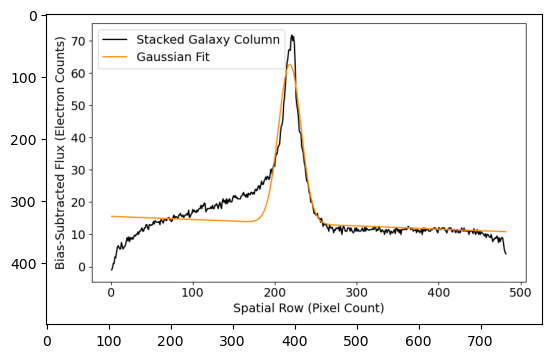

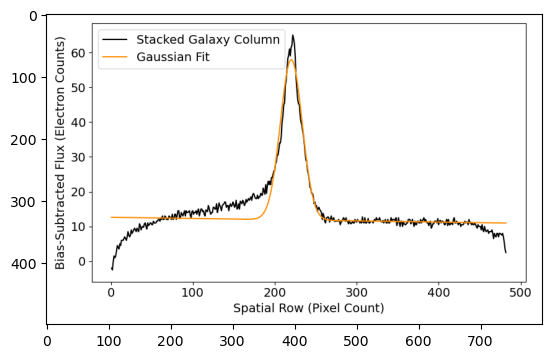

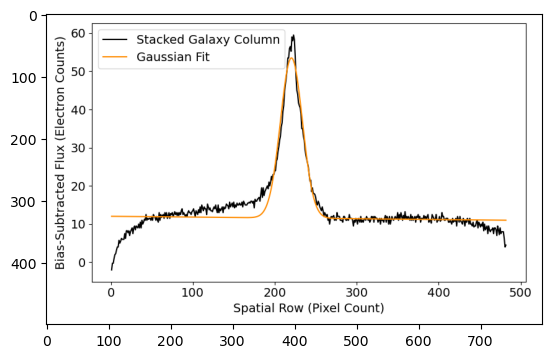

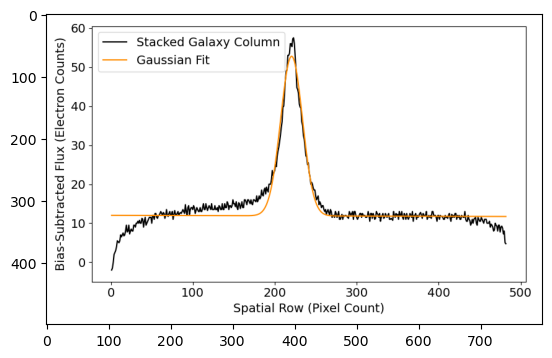

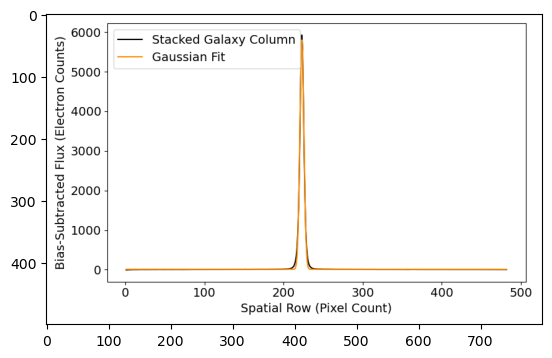

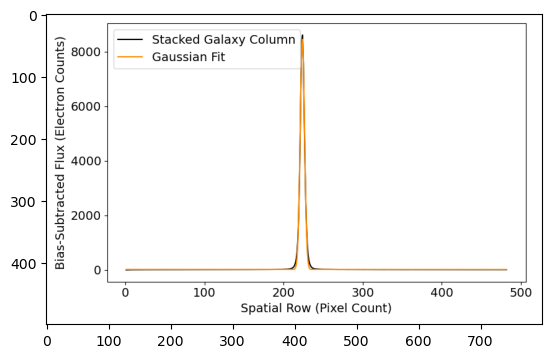

In [45]:
import matplotlib.image as mpimg
for i in range(number_of_galaxy_files):
    name = galaxy_name + "_" + str(i+1)
    plt.figure()
    plt.imshow(mpimg.imread(path + "Working Files/Centering/"+ name +"/Fit/"+name +" Fit Slice.png"))
    
for i in range(number_of_star_files):
    name = standard_star_name + "_" + str(i+1)
    plt.figure()
    plt.imshow(mpimg.imread(path + "Working Files/Centering/"+ name +"/Fit/"+name +" Fit Slice.png"))
    

    



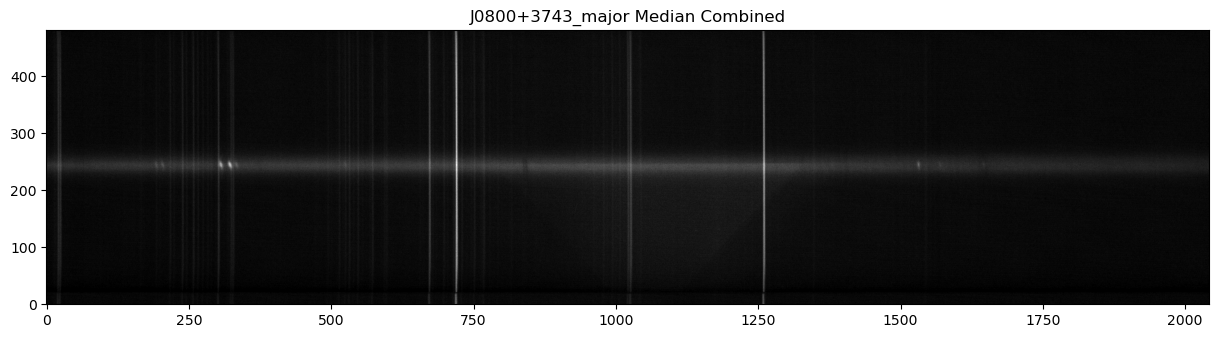

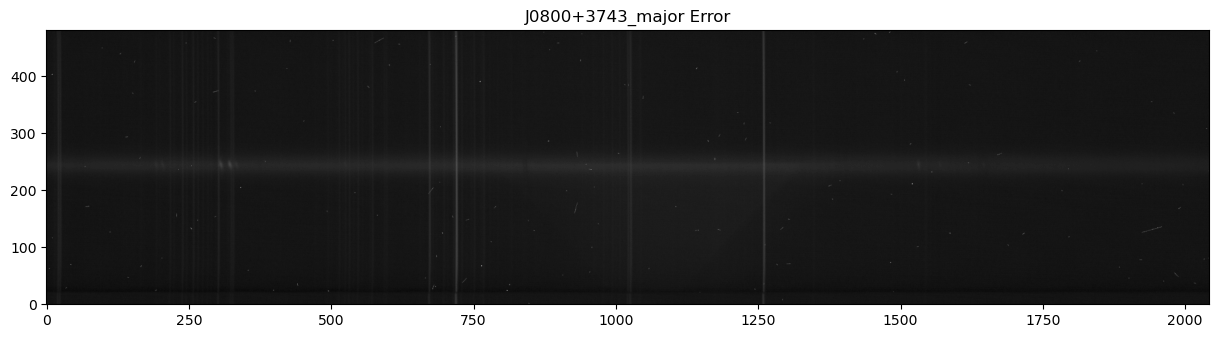

In [52]:
#Median combining to create a master galaxy file
stacked_gal = []
stacked_gal_errors = []
for i in range(number_of_galaxy_files):
    gframe = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + galaxy_name + "_ET_"+ str(i+1) +".fits")
    gdata = gframe[0].data
    gedata = gframe[1].data**2
    stacked_gal.append(gdata)
    stacked_gal_errors.append(gedata)
        
    
master_galaxy = np.nanmedian(stacked_gal, axis = 0)
galerror_quad = np.nansum(stacked_gal_errors, axis = 0)
gmean_var = galerror_quad/number_of_galaxy_files
gmedian_var = (np.pi/2)*gmean_var
gmedian_std = np.sqrt(abs(gmedian_var))


plt.figure(figsize=(15,5))
row_slice = np.resize(gmedian_std[target_row-1:target_row,:], 2042)
plt.plot(row_slice)
plt.title("Row "+target_row_script+" Error Master " + galaxy_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error " + galaxy_name + " (st. dev.)")
if not os.path.exists(path + "Working Files/Error Propagation/Median Combined Science Error/"):
        os.makedirs(path + "Working Files/Error Propagation/Median Combined Science Error/")
plt.savefig(path + "Working Files/Error Propagation/Median Combined Science Error/Median Combined " + galaxy_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()
    
plt.figure(figsize=(15,15))
plt.imshow(master_galaxy,origin="lower",cmap="gray",vmin=0)   
plt.title(galaxy_name + " Median Combined")

plt.figure(figsize=(15,15))
plt.imshow(gmedian_std,origin="lower",cmap="gray",vmin=0)   
plt.title(galaxy_name + " Error") 
   
hdu_mgalaxy = fits.PrimaryHDU(master_galaxy)
hdu_emgalaxy = fits.ImageHDU(gmedian_std)
MG_Frame = fits.HDUList([hdu_mgalaxy,hdu_emgalaxy])
MG_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Stack_" + galaxy_name + ".fits",overwrite=True)


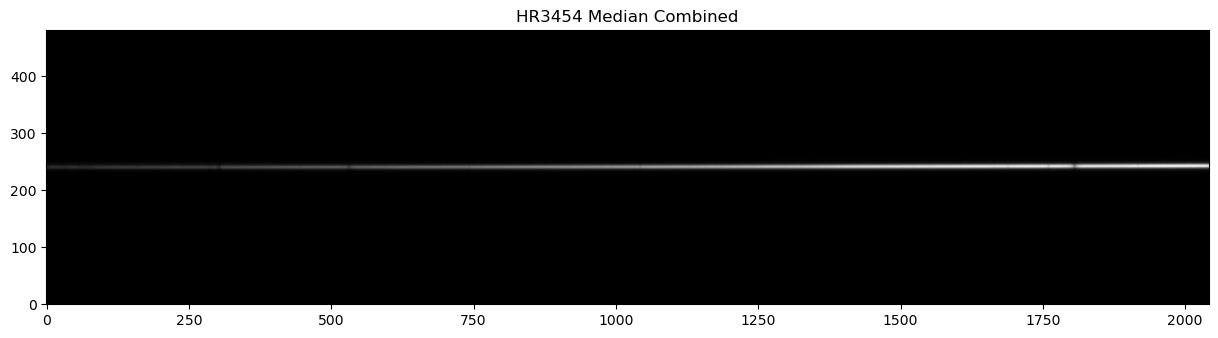

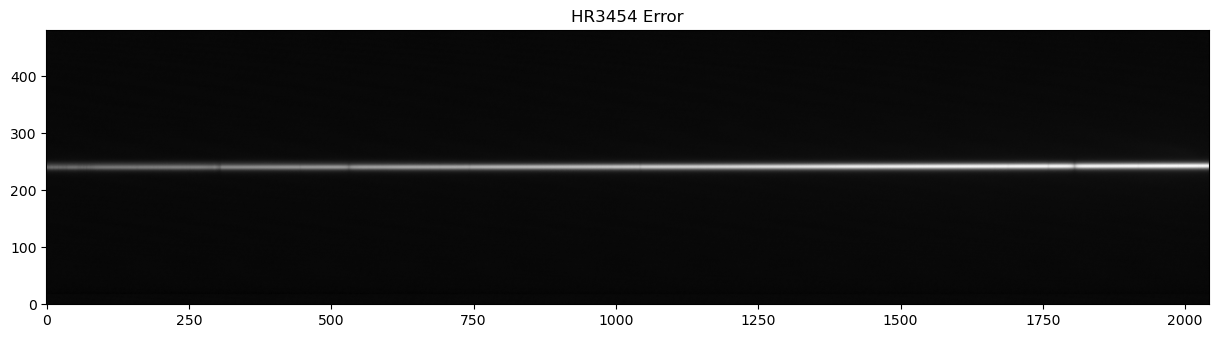

In [54]:
#Median combining to create a master star file
stacked_str = []
stacked_str_errors = []
for i in range(number_of_star_files):
    sframe = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + standard_star_name + "_ET_"+ str(i+1) +".fits")
    sdata = sframe[0].data
    sedata = sframe[1].data**2
    stacked_str.append(sdata)
    stacked_str_errors.append(sedata)
        
    
master_star = np.nanmedian(stacked_str, axis = 0)
starerror_quad = np.nansum(stacked_str_errors, axis = 0)
smean_var = starerror_quad/number_of_star_files
smedian_var = (np.pi/2)*smean_var
smedian_std = np.sqrt(abs(smedian_var))


plt.figure(figsize=(15,5))
rowz_slice = np.resize(smedian_std[target_row-1:target_row,:], 2042)
plt.plot(rowz_slice)
plt.title("Row " + target_row_script + " Error Master " + standard_star_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error " + standard_star_name + " (st. dev.)")
plt.savefig(path + "Working Files/Error Propagation/Median Combined Science Error/Median Combined " + standard_star_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

plt.figure(figsize=(15,15))
plt.imshow(master_star,origin="lower",cmap="gray",vmin=0)   
plt.title(standard_star_name + " Median Combined")

plt.figure(figsize=(15,15))
plt.imshow(smedian_std,origin="lower",cmap="gray",vmin=0)   
plt.title(standard_star_name + " Error") 

hdu_mstar = fits.PrimaryHDU(master_star)
hdu_emstar = fits.ImageHDU(smedian_std)
MS_Frame = fits.HDUList([hdu_mstar,hdu_emstar])
MS_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Stack_" + standard_star_name + ".fits",overwrite=True)

In [63]:
#Dome division to get rid of biases towards the outer edges of the galaxy
dome_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Dome_Flat_" + setting + ".fits")
galaxy_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Stack_" + galaxy_name + ".fits")

dome_data = dome_frame[0].data
dome_error = dome_frame[1].data
galaxy_data = galaxy_frame[0].data
galaxy_err_data = galaxy_frame[1].data
galaxy_data2 = galaxy_data/dome_data

#To get rid of nans from dividing by 0, we use nansum. 
#The division by 0 creates infs that results in nans--but by creating nans earlier, we can use nansum!
galaxy_data[galaxy_data == 0] = np.nan
error_prop_gal_part_2 = (galaxy_err_data/galaxy_data)**2
error_dome_part = (dome_error/dome_data)**2
summ = np.nansum(np.stack((error_prop_gal_part_2,error_dome_part)), axis=0)
dome_div_err_galaxy = abs(galaxy_data2)*np.sqrt(summ)

plt.figure(figsize=(15,5))
row_slice = np.resize(dome_div_err_galaxy[target_row-1:target_row,:], 2042)
plt.plot(row_slice)
plt.title("Row " + target_row_script + " Error Dome Divided " + galaxy_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error " + standard_star_name + " (st. dev.)")
if not os.path.exists(path + "Working Files/Error Propagation/Dome Division/"):
        os.makedirs(path + "Working Files/Error Propagation/Dome Division/")
plt.savefig(path + "Working Files/Error Propagation/Dome Division/Dome Divided " + galaxy_name + " Slice Row " + target_row_script + ".jpg",bbox_inches='tight')
plt.close()

hdu_gal_data = fits.PrimaryHDU(galaxy_data2)
hdu_err_gal_data = fits.ImageHDU(dome_div_err_galaxy)
DD_Frame = fits.HDUList([hdu_gal_data,hdu_err_gal_data])

if not os.path.exists(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/"+ "Sky and Wavelength Work/"):
        os.makedirs(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/"+ "Sky and Wavelength Work/")
DD_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Dome Divided " + galaxy_name + ".fits",overwrite=True)

In [65]:
#Dome division to get rid of biases towards the outer edges of the standard star
dome_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Dome_Flat_" + setting + ".fits")
standard_star_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Stack_" + standard_star_name + ".fits")

dome_data = dome_frame[0].data
dome_error = dome_frame[1].data
standard_star_data = standard_star_frame[0].data
standard_star_err_data = standard_star_frame[1].data
standard_star_data2 = standard_star_data/dome_data


#To get rid of nans from dividing by 0, we use nansum. 
#The division by 0 creates infs that results in nans--but by creating nans earlier, we can use nansum!
standard_star_data[standard_star_data == 0] = np.nan
error_prop_star_part_2 = (standard_star_err_data/standard_star_data)**2
error_dome_part2 = (dome_error/dome_data)**2
summ2 = np.nansum(np.stack((error_prop_star_part_2,error_dome_part2)), axis=0)
dome_div_err_standard_star = abs(standard_star_data2)*np.sqrt(summ2)

plt.figure(figsize=(15,5))
rowd_slice = np.resize(dome_div_err_standard_star[target_row-1:target_row,:], 2042)
plt.plot(rowd_slice)
plt.title("Row " + target_row_script + " Error Dome Divided " + standard_star_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error " + standard_star_name + " (st. dev.)")
plt.savefig(path + "Working Files/Error Propagation/Dome Division/Dome Divided " + standard_star_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

hdu_star_data = fits.PrimaryHDU(standard_star_data2)
hdu_err_star_data = fits.ImageHDU(dome_div_err_standard_star)
DDS_Frame = fits.HDUList([hdu_star_data,hdu_err_star_data])


DDS_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Dome Divided " + standard_star_name + ".fits",overwrite=True)

In [67]:
#Set the boundaries for sky subtraction for both the galaxy and standard star

#bottom region of spectrum:
sky_zone_1 = 50
sky_zone_2 = 100

#top region of spectrum:
sky_zone_3 = 382
sky_zone_4 = 432

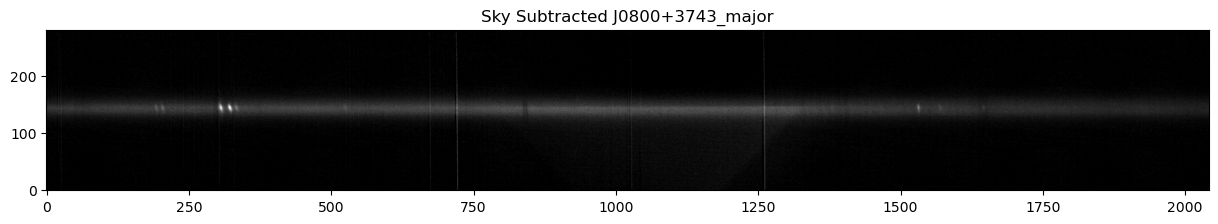

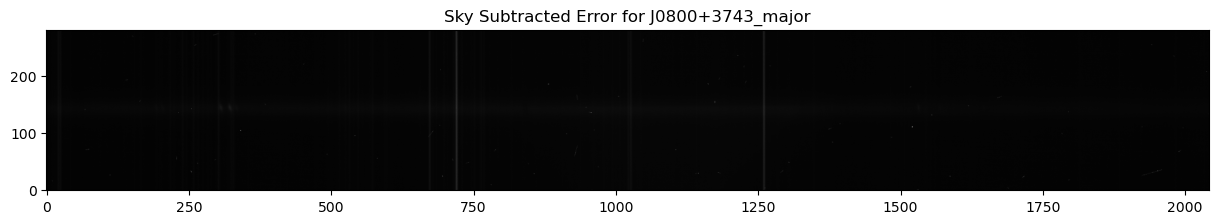

In [73]:
#Sky Subtraction step
galaxy = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Dome Divided " + galaxy_name + ".fits")
galaxy_data = galaxy[0].data
galaxy_error = galaxy[1].data

for column in range((galaxy_data.shape[1])): 
    #take median from top and bottom sky zones of a particular column
    y = galaxy_data[:, column]
    array= np.asarray(y[sky_zone_1:sky_zone_2])
    new1= np.append(array,y[sky_zone_3:sky_zone_4])
    #resize data to be between the two sky zones only
    data = galaxy_data[sky_zone_2:sky_zone_3, :]
    #subtract that median from the rest of the data in that column
    data[:,column]=data[:,column]-np.nanmedian(new1)
    error_y = galaxy_error[:,column]
    error_array = np.asarray(error_y[sky_zone_1:sky_zone_2])
    new2 = np.append(error_array,error_y[sky_zone_3:sky_zone_4])
    #error propagation steps:
    quadrature = sum(i*i for i in new2)
    quadrature = quadrature/len(new2)
    #resize error data to be between the two sky zones only
    error_data = galaxy_error[sky_zone_2:sky_zone_3, :]
    error_data[:,column] = error_data[:,column]**2 + quadrature
    
plt.figure(figsize=(15,5))
rowz_slice = np.resize(error_data[target_row-1:target_row,:], 2042)
plt.plot(rowz_slice)
plt.title("Row " + target_row_script + " Error SkySub " + galaxy_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error SkySub " + galaxy_name + " (var.)")
if not os.path.exists(path + "Working Files/Error Propagation/Sky Subtraction/"):
        os.makedirs(path + "Working Files/Error Propagation/Sky Subtraction/")
plt.savefig(path + "Working Files/Error Propagation/Sky Subtraction/Sky Subtracted Error " + galaxy_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

plt.figure(figsize=(15,15))
plt.imshow(data,origin="lower",cmap="gray",vmin=0)  
plt.title("Sky Subtracted " + galaxy_name)

plt.figure(figsize=(15,15))
plt.imshow(error_data,origin="lower",cmap="gray",vmin=0)  
plt.title("Sky Subtracted Error for " + galaxy_name)

hdu_sky_gal_data = fits.PrimaryHDU(data)
hdu_err_sky_gal_data = fits.ImageHDU(error_data)
Sky_gal_Frame = fits.HDUList([hdu_sky_gal_data,hdu_err_sky_gal_data])



Sky_gal_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Sky Subtracted " + galaxy_name + ".fits",overwrite=True)


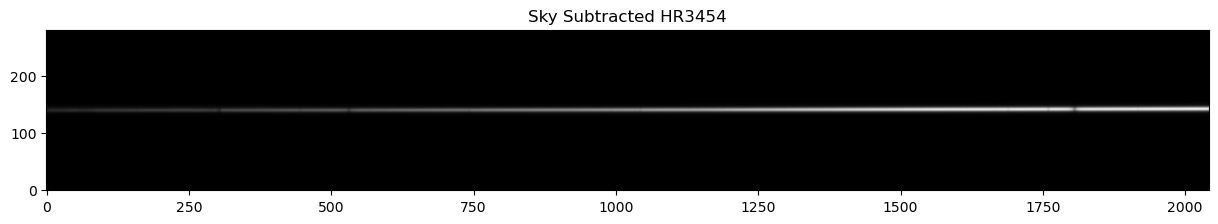

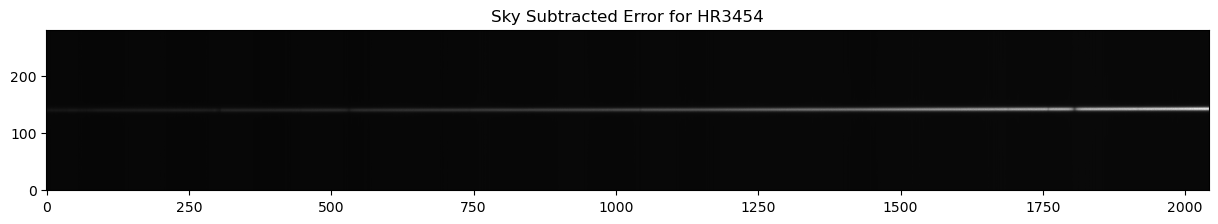

In [75]:
#Sky Subtraction step
standard_st = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Dome Divided " + standard_star_name + ".fits")
st_data = standard_st[0].data
st_error = standard_st[1].data

for column in range((galaxy_data.shape[1])):
    #take median from top and bottom sky zones of a particular column
    y = st_data[:, column]
    array= np.asarray(y[sky_zone_1:sky_zone_2])
    new1= np.append(array,y[sky_zone_3:sky_zone_4])
    #resize data to be between the two sky zones only
    data = st_data[sky_zone_2:sky_zone_3, :]
    #subtract that median from the rest of the data in that column
    data[:,column] = data[:,column] - np.nanmedian(new1)
    error_y = st_error[:,column]
    error_array = np.asarray(error_y[sky_zone_1:sky_zone_2])
    new2 = np.append(error_array,error_y[sky_zone_3:sky_zone_4])
    #error propagation steps:
    quadrature = sum(i*i for i in new2)
    #resize error data to be between the two sky zones only
    error_data = st_error[sky_zone_2:sky_zone_3, :]
    error_data[:,column] = error_data[:,column]**2 + quadrature
    
    
plt.figure(figsize=(15,5))
rowz_slice = np.resize(error_data[target_row-1:target_row,:], 2042)
plt.plot(rowz_slice)
plt.title("Row " + target_row_script + " Error SkySub " + standard_star_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error SkySub " + standard_star_name + " (var.)")
if not os.path.exists(path + "Working Files/Error Propagation/Sky Subtraction/"):
        os.makedirs(path + "Working Files/Error Propagation/Sky Subtraction/")
plt.savefig(path + "Working Files/Error Propagation/Sky Subtraction/Error SkySub " + standard_star_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

plt.figure(figsize=(15,15))
plt.imshow(data,origin="lower",cmap="gray",vmin=0)  
plt.title("Sky Subtracted " + standard_star_name)

plt.figure(figsize=(15,15))
plt.imshow(error_data,origin="lower",cmap="gray",vmin=0)  
plt.title("Sky Subtracted Error for " + standard_star_name)

hdu_sky_star_data = fits.PrimaryHDU(data)
hdu_err_sky_star_data = fits.ImageHDU(error_data)
Sky_star_Frame = fits.HDUList([hdu_sky_star_data,hdu_err_sky_star_data])



Sky_star_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Sky Subtracted " + standard_star_name + ".fits",overwrite=True)


[-1.33812451e+00  7.27014291e+03]
142.0
[[7.27014291e+03 8.03760767e-01]
 [7.26880479e+03 7.16792762e-01]
 [7.26746667e+03 7.27846086e-01]
 ...
 [4.54170703e+03 5.50271571e-01]
 [4.54036891e+03 5.44232368e-01]
 [4.53903078e+03 5.24238169e-01]]


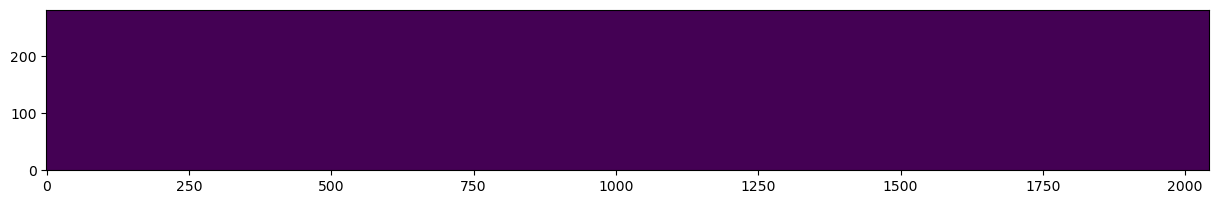

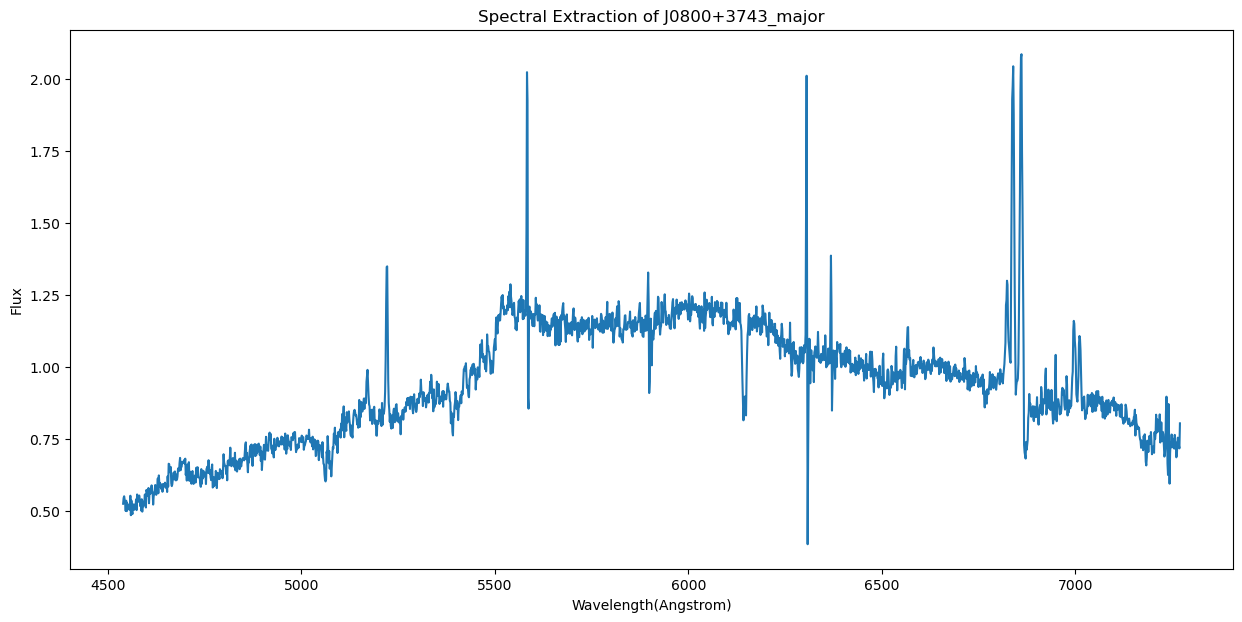

In [83]:
#Extracting spectra into a txt file and pdf graph
#The entire point of this cell is to just see spectra after sky subtraction and before flux calibration

pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(x, y, 1)
print(p)
files = np.sort(glob.glob(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Sky Subtracted " + galaxy_name + ".fits"))
window = 16
col = np.arange(galaxy_data.shape[1])

count = 1
max = []
im = fits.open(files[0],memmap=False)
image = im[0].data
image = image.astype(np.float32)
#image = np.nan_to_num(image)

for column in range(image.shape[1]):
    local_max = np.where(image[:,column] == np.amax(image[:,column]))[0][0]
    max.append(local_max)    
print(np.median(max))
peak = int(np.median(sorted(max)))
spec = np.sum(image[peak-window:peak+window,:],axis=0)
work = np.stack((col,spec),axis=-1)
work = work.astype(float)
work[:,0] = np.polyval([p[0],p[1]],work[:,0])
print(work)

if not os.path.exists(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/"):
        os.makedirs(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/")
np.savetxt(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/" + galaxy_name + "_" + str(count) + ".txt",work,delimiter='	', fmt ='%10.5f')
plt.figure(figsize=(15,15))
plt.imshow(image,origin="lower",vmax=40,vmin=0)

f=plt.figure(figsize=(15,7))
plt.plot(work[:,0],work[:,1])
plt.xlabel('Wavelength(Angstrom)',color='black')
plt.ylabel('Flux',color='black')
plt.title("Spectral Extraction of " + galaxy_name,color='black')
if not os.path.exists(path + "Working Files/Sky-Subtracted/"):
        os.makedirs(path + "Working Files/Sky-Subtracted/")
f.savefig(path + "Working Files/Sky-Subtracted/Sky Subtracted Spectrum of " + galaxy_name + ".pdf",bbox_inches='tight')


[-1.33812451e+00  7.27014291e+03]
[[ 7270.14291499 16416.95507812]
 [ 7268.80479048 16137.73730469]
 [ 7267.46666596 16385.86914062]
 ...
 [ 4541.70703177 84146.        ]
 [ 4540.36890726 83946.7265625 ]
 [ 4539.03078274 84391.0859375 ]]


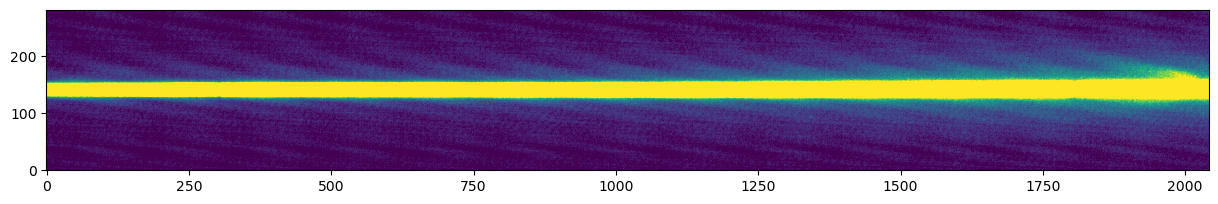

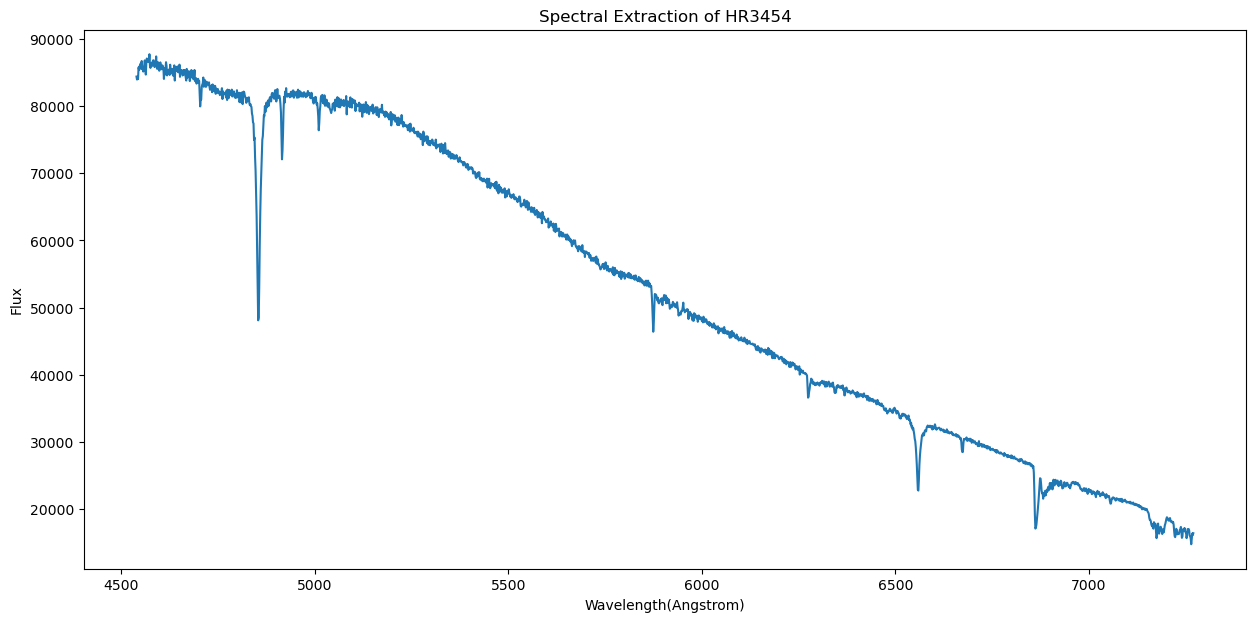

In [85]:
#Extracting spectra into a txt file and pdf graph
#The entire point of this cell is to just see spectra after sky subtraction and before flux calibration

pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(x, y, 1)
print(p)

files = np.sort(glob.glob(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Sky Subtracted " + standard_star_name + ".fits"))

window = 16
col = np.arange(galaxy_data.shape[1])


count = 1
max = []
im = fits.open(files[0],memmap=False)
image = im[0].data
image = image.astype(np.float32)
#image = np.nan_to_num(image)

for column in range(image.shape[1]):
    local_max = np.where(image[:,column] == np.amax(image[:,column]))[0][0]
    max.append(local_max)    
peak = int(np.median(sorted(max)))
spec = np.sum(image[peak-window:peak+window,:],axis=0)
work = np.stack((col,spec),axis=-1)
work = work.astype(float)
work[:,0] = np.polyval([p[0],p[1]],work[:,0])
print(work)
np.savetxt(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/" + standard_star_name + "_" + str(count) + ".txt",work,delimiter='	', fmt ='%10.5f')
plt.figure(figsize=(15,15))
plt.imshow(image,origin="lower",vmax=40,vmin=0)


f=plt.figure(figsize=(15,7))
plt.plot(work[:,0],work[:,1])
plt.xlabel('Wavelength(Angstrom)',color='black')
plt.ylabel('Flux',color='black')
plt.title("Spectral Extraction of " + standard_star_name,color='black')
f.savefig(path + "Working Files/Sky-Subtracted/Sky Subtracted Spectrum of " + standard_star_name + ".pdf",bbox_inches='tight')


In [88]:
#Reading in the accepted data for the standard star from previous scientific papers
data = pd.read_csv(path + 'Standard Stars Accepted Flux Data/' + literature_standard_star_values,sep='\s+',header=None)
data = pd.DataFrame(data)

441


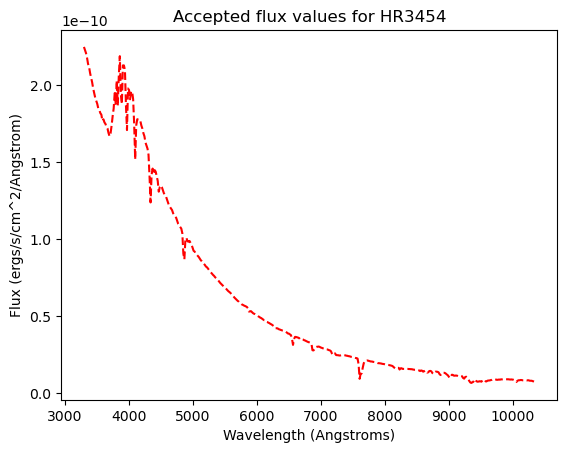

In [92]:
#Plot literature value standard star flux values
accepted_x = data[0]
accepted_y = data[1]
print(len(accepted_y))

plt.plot(accepted_x, accepted_y,'r--')
plt.title("Accepted flux values for " + standard_star_name)
plt.xlabel('Wavelength (Angstroms)')  
plt.ylabel('Flux (ergs/s/cm^2/Angstrom)') 
if not os.path.exists(path + "Working Files/Flux Calibration/"):
        os.makedirs(path + "Working Files/Flux Calibration/")
plt.savefig(path + "Working Files/Flux Calibration/Accepted flux values " + standard_star_name +".jpg",bbox_inches='tight')
plt.show()

2042


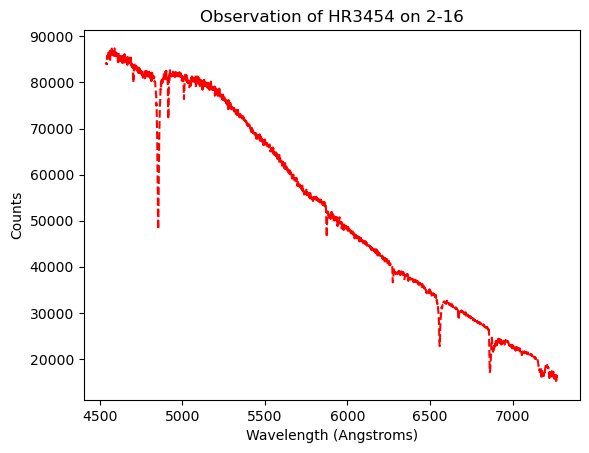

In [94]:
#Now, we load in the spectra txt file we created earlier for our standard star
data2 = pd.read_csv(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/" + standard_star_name + '_1.txt',sep='\s+',header=None)
data2 = pd.DataFrame(data2)

observed_standard_x = data2[0]
observed_standard_y = data2[1]
print(len(observed_standard_y))

plt.plot(observed_standard_x, observed_standard_y,'r--')
plt.title("Observation of " + standard_star_name + " on " + date)
plt.xlabel('Wavelength (Angstroms)')  
plt.ylabel('Counts')  
plt.savefig(path + "Working Files/Flux Calibration/Observed flux values " + standard_star_name + " " + date + ".jpg",bbox_inches='tight')


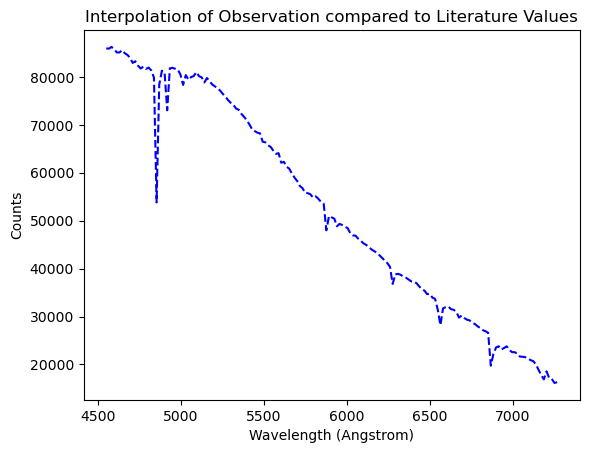

In [97]:
#We interpolate, so that our spectra values occur on the same x-axis widths as the literature values
f = interpolate.interp1d(observed_standard_x,observed_standard_y, fill_value="extrapolate")
xnew = accepted_x[(accepted_x>np.polyval([p[0],p[1]],2042))&(accepted_x<np.polyval([p[0],p[1]],-1))]
ycropped = accepted_y[(accepted_x>np.polyval([p[0],p[1]],2042))&(accepted_x<np.polyval([p[0],p[1]],-1))]
interpolated_standard_y = f(xnew)

plt.plot(xnew,interpolated_standard_y,'b--')
plt.title("Interpolation of Observation compared to Literature Values")
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Counts")
plt.savefig(path + "Working Files/Flux Calibration/Interpolation " + standard_star_name +".jpg",bbox_inches='tight')
plt.show()

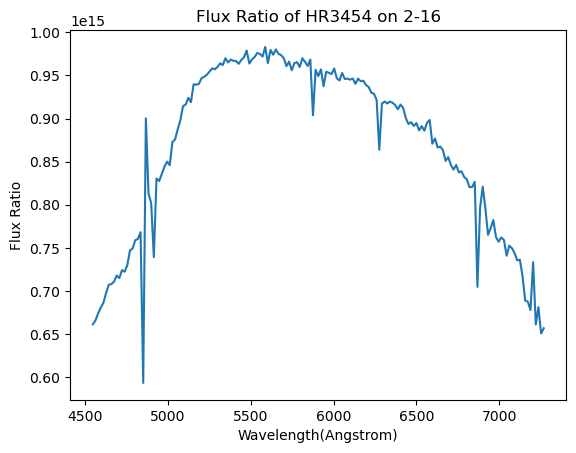

In [99]:
#We now divide out our observed/accept values at each wavelength to get a flux ratio
flux_ratio = interpolated_standard_y / ycropped #observation / accepted
plt.plot(xnew,flux_ratio)
plt.title("Flux Ratio of " +standard_star_name + " on "+ date)
plt.xlabel("Wavelength(Angstrom)")
plt.ylabel("Flux Ratio")
plt.savefig(path + "Working Files/Flux Calibration/Flux Ratio of " + standard_star_name + " " + date + ".jpg",bbox_inches='tight')
plt.show()

polyfit polynomial:  -1.30976134e+16 + (6.26447104e+12)·x - (9.01210056e+08)·x² +
41294.22417954·x³
-------------
r-squared trial: 0.9265339065145439


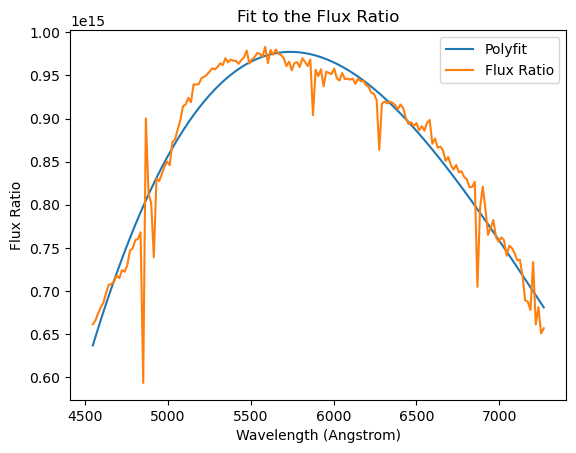

In [101]:
x_fit= xnew
y_fit= flux_ratio
#fit a third order polynomial to flux ratio
polyfit= poly.polyfit(x_fit, y_fit, 3)

ffit = poly.Polynomial(polyfit)    # instead of np.poly1d
print("polyfit polynomial: ", ffit)
print("-------------")

plt.plot(x_fit, ffit(x_fit), label = "Polyfit")
plt.plot(x_fit,y_fit, label = "Flux Ratio")
plt.title("Fit to the Flux Ratio")
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux Ratio")
plt.legend()



#Trying to calculate r squared value to see how good the fit is. . .
res = ffit(x_fit).sub(y_fit).pow(2).sum()
tot = ffit(x_fit).sub(ffit(x_fit).mean()).pow(2).sum()
r2 = 1 - res/tot
print("r-squared trial:", r2)

In [104]:
fig = plt.figure(figsize=(12, 3))
gs = gridspec.GridSpec(1, 3, wspace=0.3)  # 4:1 width ratio

# Main plot
ax_left = fig.add_subplot(gs[0])

# Side histogram (right)
#ax_hist = fig.add_subplot(gs[1,1], sharey=ax_main)  # Share y-axis for alignment

ax_center = fig.add_subplot(gs[1])

ax_right = fig.add_subplot(gs[2])


ax_left.plot(accepted_x, accepted_y,'r--')
#plt.title("Accepted flux values for " + standard_star_name)
ax_left.set_xlabel('Wavelength ($\AA$)', fontsize = 12)  
ax_left.set_ylabel('Flux (erg/s/$cm^2$/$\AA$)', fontsize = 12)  


ax_center.plot(observed_standard_x, observed_standard_y,'r--')
#plt.title("Observation of " + standard_star_name + " on " + date)
ax_center.set_xlabel('Wavelength ($\AA$)', fontsize = 12)  
ax_center.set_ylabel('Counts', fontsize = 12)  

ax_right.plot(x_fit, ffit(x_fit), label = "Polyfit", color = "blue", zorder = 3)
ax_right.plot(x_fit,y_fit, label = "Flux Ratio", color = "orange", zorder = 2)
#plt.title("Fit to the Flux Ratio")
ax_right.set_xlabel("Wavelength ($\AA$)", fontsize = 12)
ax_right.set_ylabel("Flux Ratio", fontsize = 12)
ax_right.legend(fontsize = 12)

ax_right.tick_params(axis='x', labelsize=12)  # Change x-axis tick label size
ax_right.tick_params(axis='y', labelsize=12)  # Change x-axis tick label size

ax_center.tick_params(axis='x', labelsize=12)  # Change x-axis tick label size
ax_center.tick_params(axis='y', labelsize=12)  # Change x-axis tick label size

ax_left.tick_params(axis='x', labelsize=12)  # Change x-axis tick label size
ax_left.tick_params(axis='y', labelsize=12)  # Change x-axis tick label size

plt.tight_layout()

if not os.path.exists(path+"Working Files/Image Sets/"):
    os.makedirs(path+"Working Files/Image Sets/")
plt.savefig(path+"Working Files/Image Sets/Flux_Calibration_Figures.pdf", bbox_inches='tight')
plt.savefig(path+"Working Files/Image Sets/Flux_Calibration_Figures.png", bbox_inches='tight')
plt.close()

/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13924/3140318364.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[-7.47303090e-01  5.43301739e+03]
6.80394546e+14 + (3.90156107e+11)·x - 1007201.77155964·x² -
98946.16757091·x³


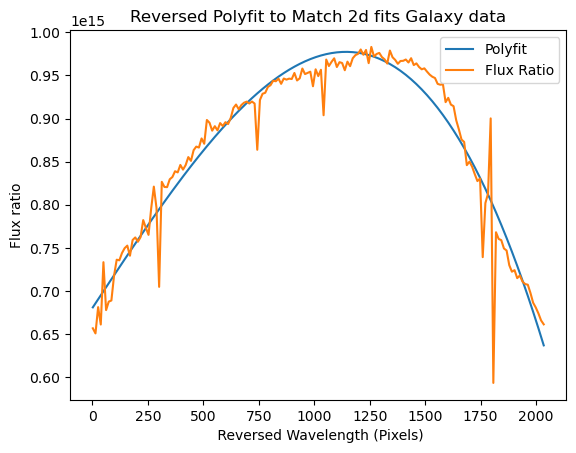

In [106]:
#Since fits file is in pixels and not angstrom, flip polyfit and flux ratio by changing x-axis
#This way, it matches the data array we will load in for flux calibration
pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(y, x, 1)
print(p)
x_fit2= np.polyval([p[0],p[1]],x_fit)

polyfit2= poly.polyfit(x_fit2, y_fit, 3)
ffit2 = poly.Polynomial(polyfit2)# instead of np.poly1d

print(ffit2)
plt.plot(x_fit2, ffit2(x_fit2), label = "Polyfit")
plt.plot(x_fit2,y_fit, label = "Flux Ratio")
plt.title("Reversed Polyfit to Match 2d fits Galaxy data")
plt.xlabel(" Reversed Wavelength (Pixels)")
plt.ylabel("Flux ratio")
plt.legend()

2042


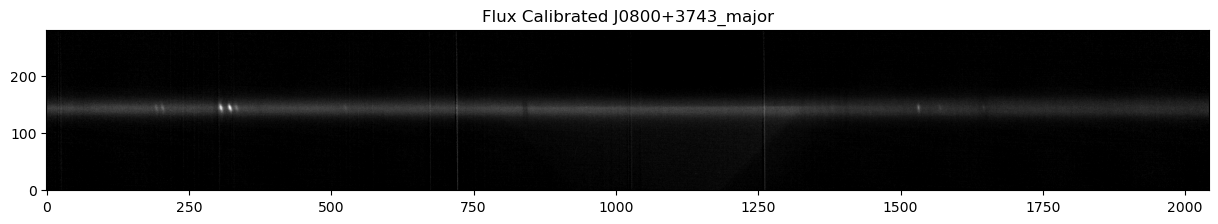

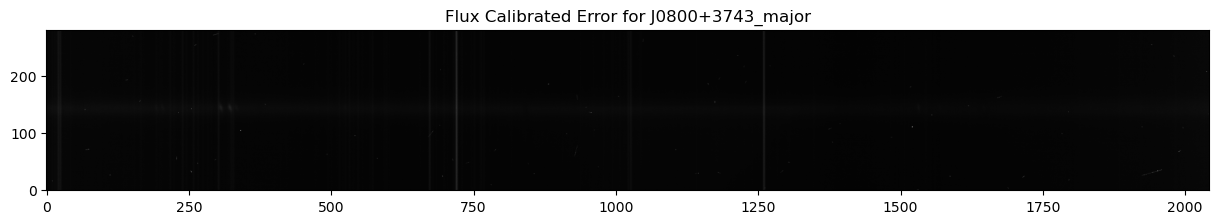

In [116]:
#Flux Calibration using the flux ratio just created above from standard star
frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Sky Subtracted " + galaxy_name + ".fits")
data = frame[0].data
errordata = frame[1].data
print(data.shape[1])

#Apply flux calibration
for column in range((data.shape[1])):
    data[:,column]= data[:,column]/ffit2(column)
    errordata[:,column]= errordata[:,column]/ffit2(column)**2

plt.figure(figsize=(15,5))
rowy_slice = np.resize(errordata[target_row-1:target_row,:], 2042)
plt.plot(rowy_slice)
plt.title("Row " + target_row_script + " Error FluxCal " + galaxy_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error FluxCal " + galaxy_name + " (var.)")
if not os.path.exists(path + "Working Files/Error Propagation/Flux Calibration/"):
    os.makedirs(path + "Working Files/Error Propagation/Flux Calibration/")
plt.savefig(path + "Working Files/Error Propagation/Flux Calibration/Error FluxCal " + galaxy_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

plt.figure(figsize=(15,15))
plt.imshow(data,origin="lower",cmap="gray",vmin=0)  
plt.title("Flux Calibrated " + galaxy_name)

plt.figure(figsize=(15,15))
plt.imshow(errordata,origin="lower",cmap="gray",vmin=0)  
plt.title("Flux Calibrated Error for " + galaxy_name)
    
hdu_data= fits.PrimaryHDU(data)
hdu_err_data = fits.ImageHDU(errordata)
Flux_Frame = fits.HDUList([hdu_data,hdu_err_data])

#Change file path when needed
Flux_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Flux Calibrated " + galaxy_name +  ".fits",overwrite=True)

In [118]:
#Correct for Milky Way galactic extinction using values from NED database (in excel sheet in folder ;)
def ExtCorrection(galaxy_target):
    df = pd.read_excel(path + 'Galaxy Properties/Galaxy SDSS Information v2.xlsx')
    print(galaxy_target)
    ind = df[df['Galaxy'] == galaxy_target].index
    ind = ind[0]
    
    extinction_mag = df.at[ind,'A_lambda V']
    
    pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
    x = pixel[:,1]
    y = pixel[:,0]
    p = np.polyfit(x, y, 1)
    
    xaxis= np.linspace(0,2041,num=2042)
    yaxis= np.polyval([p[0],p[1]],xaxis)
    ext = extinction.odonnell94(yaxis, extinction_mag, 3.1, unit='aa')
    
    plt.plot(yaxis,ext)
    plt.title("Extinction A_lambda per wavelength")
    plt.ylabel("A_lambda (magnitude)")
    plt.xlabel("Wavelength (Angstrom)")
    if not os.path.exists(path + "Working Files/Extinction/" + galaxy_name + "/"):
            os.makedirs(path + "Working Files/Extinction/" + galaxy_name + "/")
    plt.savefig(path + "Working Files/Extinction/" + galaxy_name + "/" + galaxy_name + " Galactic Extinction.jpg",bbox_inches='tight')
    
    frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Flux Calibrated " + galaxy_name +  ".fits")
    

    flux_data = np.fliplr(frame[0].data)
    flux_error = np.fliplr(frame[1].data)
    
    print(flux_data)
    ext_corrected = extinction.remove(ext, flux_data[:,:])
    ext_corrected_error = extinction.remove(ext, flux_error[:,:])
    ext_corrected_error = extinction.remove(ext, ext_corrected_error)
    print(ext_corrected)
    print(ext_corrected.shape)
    
    test0 = frame[0].header

    test0.set('EXTNAME','DATA  ') 

    test0.set('OBJECT', galaxy_name + ' (DATA)')
    test0.set('BUNIT','erg/s/cm^2/Angstrom')

    
    
    test0.set('CTYPE1','AWAV    ') # Pixel coordinate system
    test0.set('CUNIT1','Angstrom')
    test0.set('CRPIX1',0.0) # Reference pixel in axis1
    test0.set('CRVAL1', np.polyval([p[0],p[1]],2041)) #The reference data coordinates corresponding to CRPIX1 and CRPIX2.
    test0['CRVAL1'] = (np.polyval([p[0],p[1]],2041),'Starting wavelength value')
    test0.set('CDELT1',round(np.abs(p[0]),8)) #The width and heighth of a pixel in data units. 
    test0['CDELT1'] = (round(np.abs(p[0]),8),'Wavelength scale in Angstrom per pixel')

    
    
    test0.set('CTYPE2','PIXEL') # Pixel coordinate system
    test0.set('CUNIT2','ARCSEC')
    test0['CUNIT2'] = ('ARCSEC','Above/below galactic plane')
    test0.set('CRPIX2',141.0) # Reference pixel in axis3
    test0['CRPIX2'] = (141.0,'Center of galaxy')
    test0.set('CRVAL2', 0.0) #The reference data coordinates corresponding to CRPIX1 and CRPIX2.
    test0.set('CDELT2', 0.34) #The width and heighth of a pixel in data units. 
    test0['CDELT2'] = (0.34,'Unbinned spatial scale in arcsec per pixel')
    print(repr(test0))
    
    spectrum_hdu = fits.PrimaryHDU(ext_corrected)
    error_hdu = fits.ImageHDU(ext_corrected_error)
    data_cube = fits.HDUList([spectrum_hdu,error_hdu])
    data_cube[0].header = test0

    #Change file path when needed
    data_cube.writeto(path + "Flux Calibrated SPOGs/" + galaxy_name + "_Flux_Calibrated.fits",overwrite=True)
    trial = fits.open(path + "Flux Calibrated SPOGs/" + galaxy_name + "_Flux_Calibrated.fits")
    trial.info()
    trial.close()
    

J0800+3743
[[ 7.07936379e-19 -1.25137853e-18  3.07887301e-18 ... -5.87977761e-18
   2.19976899e-18  5.73006763e-18]
 [ 4.47317788e-18 -1.57417077e-18 -2.03704834e-18 ... -5.77849117e-19
   4.82026748e-18  1.76837465e-17]
 [-2.77832450e-18 -7.00663188e-18  1.47434261e-18 ...  4.16088505e-18
  -1.11773217e-18  1.29869023e-17]
 ...
 [ 2.51601112e-18  2.83519518e-18 -4.10914283e-18 ...  6.32763585e-18
  -9.62790962e-19 -2.40231188e-18]
 [ 1.35586440e-18  5.10109579e-19 -3.03721469e-18 ...  1.87158004e-18
  -1.06375397e-18 -1.02736343e-17]
 [ 2.29128007e-18 -3.34955988e-18  2.47531175e-18 ... -6.62969515e-18
   1.02816419e-18 -5.78236911e-18]]
[[ 7.76438020e-19 -1.37249854e-18  3.37695750e-18 ... -6.93584792e-18
   2.59500490e-18  6.75994692e-18]
 [ 4.90601341e-18 -1.72653360e-18 -2.23426742e-18 ... -6.81636936e-19
   5.68633241e-18  2.08620902e-17]
 [-3.04716192e-18 -7.68479864e-18  1.61708272e-18 ...  4.90822406e-18
  -1.31855684e-18  1.53210706e-17]
 ...
 [ 2.75946645e-18  3.10961164e-18

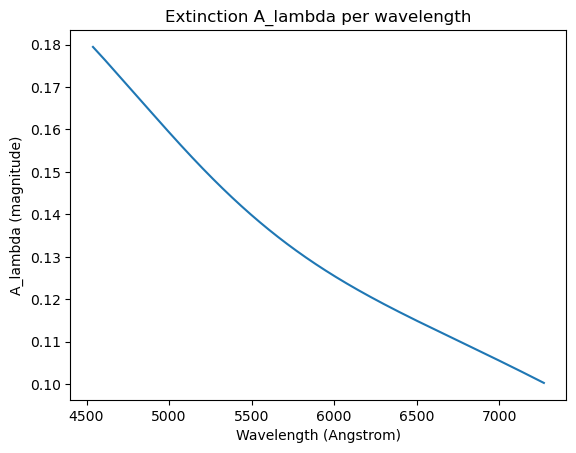

In [120]:
ExtCorrection(galaxy_name_2)

In [122]:
print(p[0])
print(p[1]+2041*p[0])

-0.7473030897476004
3907.7717789524204


[-1.33812451e+00  7.27014291e+03]
[4539.03078274 4540.36890726 4541.70703177 ... 7267.46666596 7268.80479048
 7270.14291499]
(2042,)


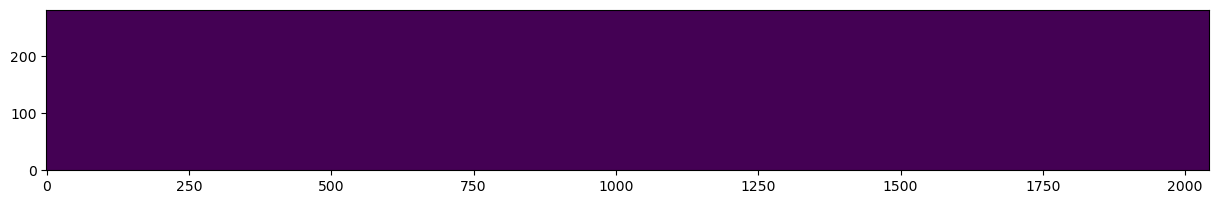

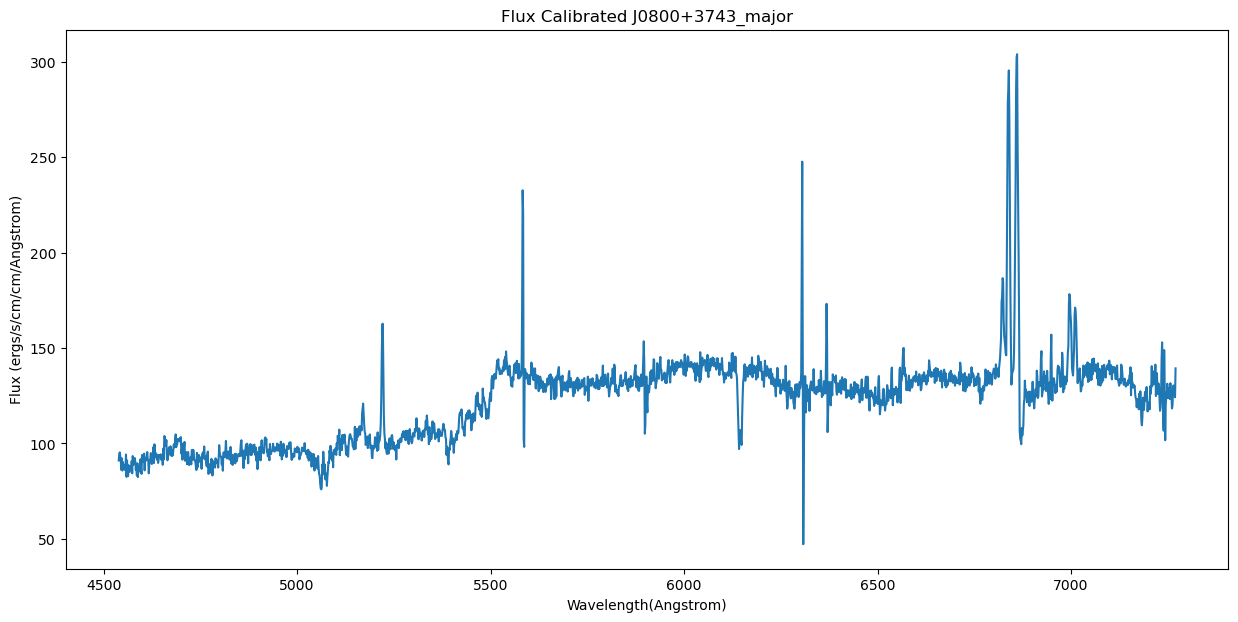

In [124]:
#Extracting spectra into a txt file and pdf graph

#Change file path when needed
pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(x, y, 1)
print(p)
#Change file path when needed
files = np.sort(glob.glob(path + "Flux Calibrated SPOGs/" + galaxy_name + "_Flux_Calibrated.fits"))

window = 16
col = np.arange(galaxy_data.shape[1])


count = 1
max = []
im = fits.open(files[0],memmap=False)
image = im[0].data
image = image.astype(np.float32)
#image = np.nan_to_num(image)

for column in range(image.shape[1]):
    local_max = np.where(image[:,column] == np.amax(image[:,column]))[0][0]
    max.append(local_max)    
peak = int(np.median(sorted(max)))
spec = np.sum(image[peak-window:peak+window,:],axis=0)
work = np.stack((col,spec),axis=-1)
work = work.astype(float)
work[:,0] = np.polyval([-p[0],(p[1]+2041*p[0])],work[:,0])
print(work[:,0])
print(work[:,0].shape)

work[:,1] = work[:,1] * flux_correction
np.savetxt(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Sky and Wavelength Work/Spectra Txt/Flux Calibrated_" + galaxy_name + "_" + str(count) + ".txt",work,delimiter='	', fmt ='%10.5f')
plt.figure(figsize=(15,15))
plt.imshow(image,origin="lower",vmax=40,vmin=0)


f=plt.figure(figsize=(15,7))
plt.plot(work[:,0],work[:,1])
plt.xlabel('Wavelength(Angstrom)',color='black')
plt.ylabel('Flux (ergs/s/cm/cm/Angstrom)',color='black')
plt.title("Flux Calibrated " + galaxy_name,color='black')
f.savefig(path + "Working Files/Flux Calibration/Flux Calibrated Spectrum of " + galaxy_name + ".pdf")
